#   Lab 47: Moving Averages and Smoothing Techniques

## ❂ Purpose

In this lab, you will learn how smoothing methods help make noisy time series data easier to understand. You will create a realistic stock-price-style dataset, calculate simple moving averages, apply exponential smoothing, compare different smoothing methods, evaluate responsiveness and lag, analyze short-term and long-term trends, and explore a practical example using moving-average crossover signals.

This lab is designed for Google Colab and includes all required code directly in the notebook workflow.

---

## ❂ Objectives

By the end of this lab, students should be able to:
- Understand the concept of moving averages and their applications in time series analysis
- Implement rolling means using Python and pandas
- Apply exponential smoothing techniques to time series data
- Compare the effectiveness of different smoothing methods
- Visualize short-term and long-term trends in time series data
- Interpret smoothed data to identify underlying patterns and trends
- Evaluate smoothing methods using basic performance metrics
- Use moving-average-based logic to generate simple trend-following signals

## ❂ Prerequisites

Students should have:
- Basic understanding of Python programming
- Familiarity with pandas
- Basic knowledge of matplotlib
- Understanding of simple statistical concepts
- Some exposure to time series data is helpful, but not required

## ⚙  Environment Setup

### ELI10
Before we analyze data, we need the right tools. These tools help us create data, store it in tables, smooth it, and draw charts.

We are installing `pandas` (for tables), `numpy` (for math), `matplotlib` and `seaborn` (for drawing charts).

In [1]:
!pip install -q pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ignore warnings to keep the output clean
warnings.filterwarnings("ignore")

# Set up professional plotting style for Colab
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (12, 8)
sns.set_palette("husl")

## ᐅ  Creating the Dataset

### ELI10
Instead of using a real stock market file, we will create our own realistic time series. This keeps the lab simple, reproducible, and fully runnable in Colab.

The dataset will behave like stock prices by including:
* A long-term upward trend (the general direction)
* Repeating yearly seasonality (patterns that repeat every year)
* Random noise (tiny daily changes that make the line look 'shaky')

In [3]:
# Set random seed for reproducibility
np.random.seed(42)

# Create date range from 2020 to 2023
dates = pd.date_range(start="2020-01-01", end="2023-12-31", freq="D")

# Generate synthetic stock-like price components
trend = np.linspace(100, 200, len(dates)) # Gradual rise from 100 to 200
seasonal = 10 * np.sin(2 * np.pi * np.arange(len(dates)) / 365.25) # Annual waves
noise = np.random.normal(0, 5, len(dates)) # Random daily wiggle

# Combine components into a single price series
price = trend + seasonal + noise

# Construct the DataFrame
df = pd.DataFrame({
    "date": dates,
    "price": price
})

# Set date as index and ensure daily frequency
df.set_index("date", inplace=True)
df = df.asfreq("D")

print("Dataset created successfully!")
print(f"Data shape: {df.shape}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
display(df.head())

Dataset created successfully!
Data shape: (1461, 1)
Date range: 2020-01-01 to 2023-12-31


,price
date,
2020-01-01,102.483571
2020-01-02,99.549187
2020-01-03,103.719410
2020-01-04,108.336472
2020-01-05,99.790760


## ᐁ  Exploring the Original Series

### ELI10
Before smoothing anything, we first need to look at the raw data. This helps us understand how noisy the signal is and why smoothing can be useful to see the bigger picture.

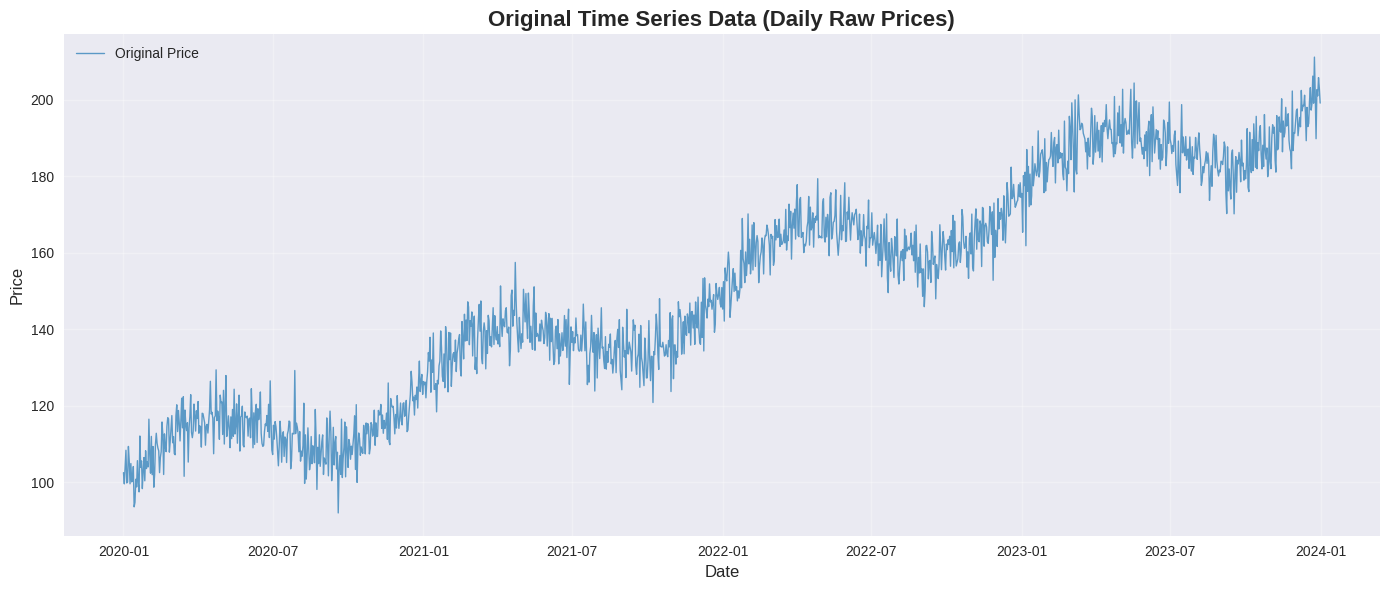


Descriptive Statistics for Original Series:


,price
count,1461.000000
mean,150.225117
std,29.017697
min,91.948980
25%,124.890196
50%,149.663225
75%,175.504675
max,211.157109


In [4]:
# Plot the original price data
plt.figure(figsize=(14, 6))
plt.plot(df.index, df["price"], alpha=0.7, linewidth=1, label="Original Price", color='tab:blue')
plt.title("Original Time Series Data (Daily Raw Prices)", fontsize=16, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Display summary statistics
print("\nDescriptive Statistics for Original Series:")
display(df["price"].describe())

## ᐦ  Simple Moving Averages

### ELI10
A moving average takes the average of the most recent values in a window (like the last 7 days). This makes sudden jumps less noisy.
- A **small window** (like 7 days) reacts quickly but stays a bit shaky.
- A **large window** (like 365 days) is very smooth but reacts very slowly to changes.

In [5]:
# Calculate short-term moving averages
for w in [7, 14, 30]:
    df[f"MA_{w}"] = df["price"].rolling(window=w).mean()
    print(f"Completed {w}-day Moving Average")

# Calculate long-term moving averages
for w in [90, 180, 365]:
    df[f"MA_{w}"] = df["price"].rolling(window=w).mean()
    print(f"Completed {w}-day Moving Average")

# Display first 35 rows to see the transition from NaN to calculated values
print("\nFirst 35 rows (Note how NaNs appear until the window is full):")
display(df.head(35))

Completed 7-day Moving Average
Completed 14-day Moving Average
Completed 30-day Moving Average
Completed 90-day Moving Average
Completed 180-day Moving Average
Completed 365-day Moving Average

First 35 rows (Note how NaNs appear until the window is full):


,price,MA_7,MA_14,MA_30,MA_90,MA_180,MA_365
date,,,,,,,
2020-01-01,102.483571,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-02,99.549187,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,103.719410,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-04,108.336472,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-05,99.790760,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-06,100.030842,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-07,109.337337,103.321083,NaN,NaN,NaN,NaN,NaN
2020-01-08,105.517887,103.754556,NaN,NaN,NaN,NaN,NaN
2020-01-09,99.572427,103.757876,NaN,NaN,NaN,NaN,NaN


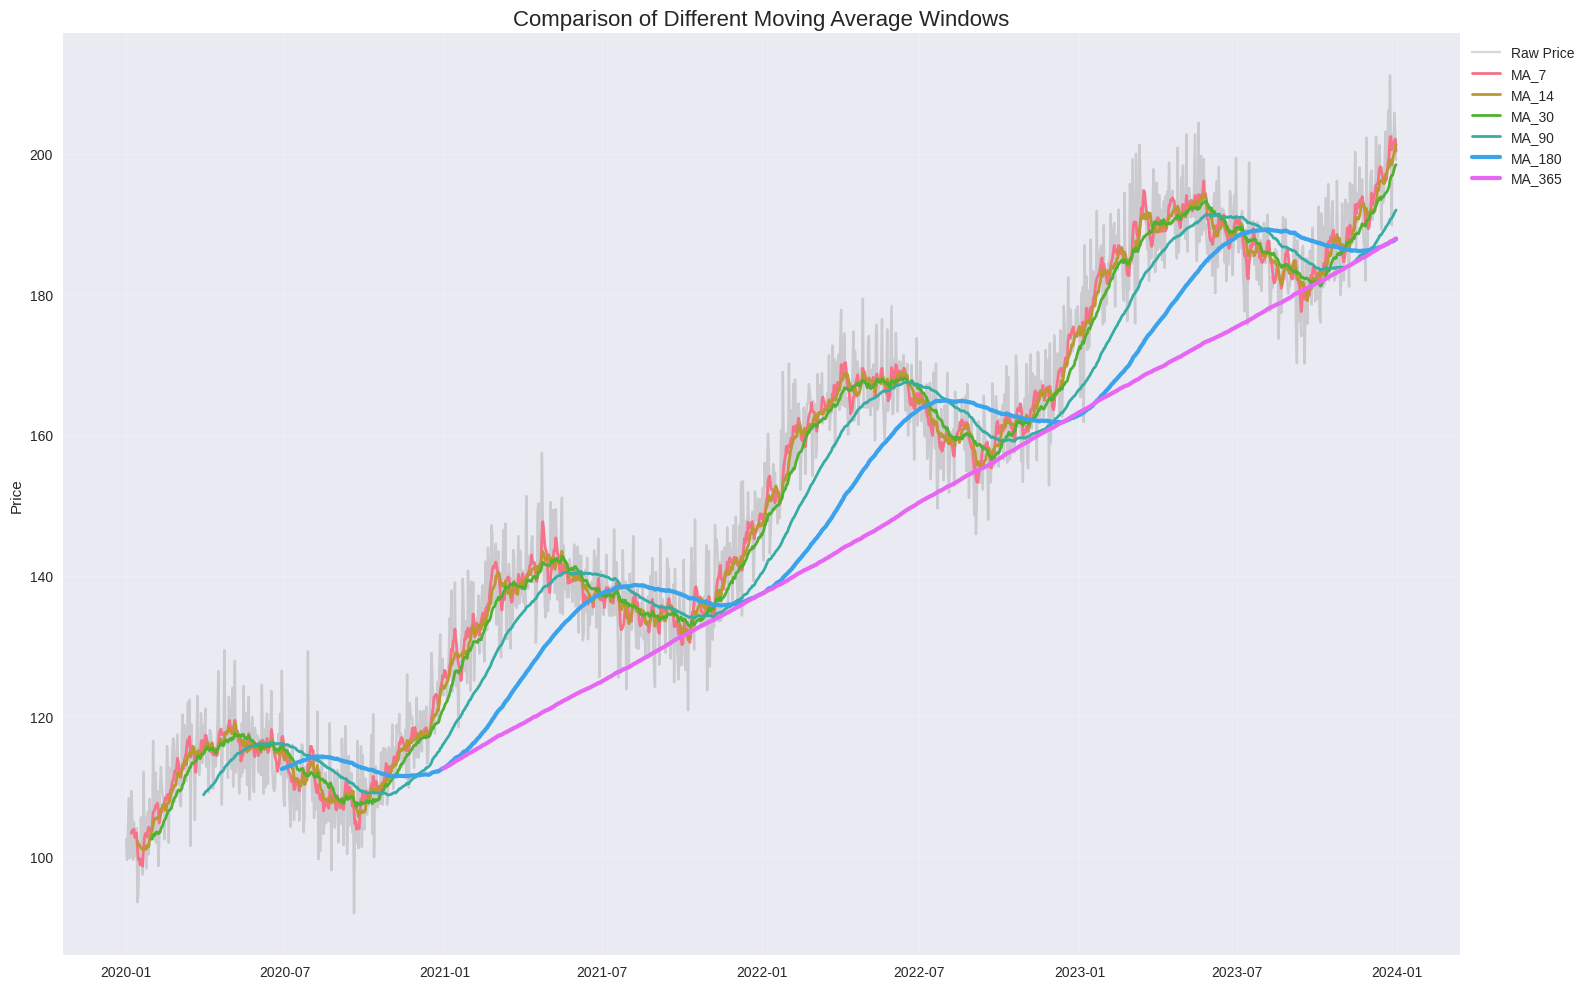

In [6]:
# Comparison Plot: Original vs All Moving Averages
plt.figure(figsize=(16, 10))
plt.plot(df.index, df["price"], alpha=0.3, color="gray", label="Raw Price")

# Plot each MA
for col in [c for c in df.columns if "MA_" in c]:
    plt.plot(df.index, df[col], label=col, linewidth=2 if int(col.split('_')[1]) < 100 else 3)

plt.title("Comparison of Different Moving Average Windows", fontsize=16)
plt.ylabel("Price")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## ⚡  Exponential Smoothing

### ELI10
A moving average treats all days in the window equally. **Exponential smoothing** is smarter: it gives more importance to today and slightly less to yesterday, getting weaker as we go back in time.

The `alpha` value controls this: high alpha means we care mostly about today (jumpy), low alpha means we look at a long history (smooth).

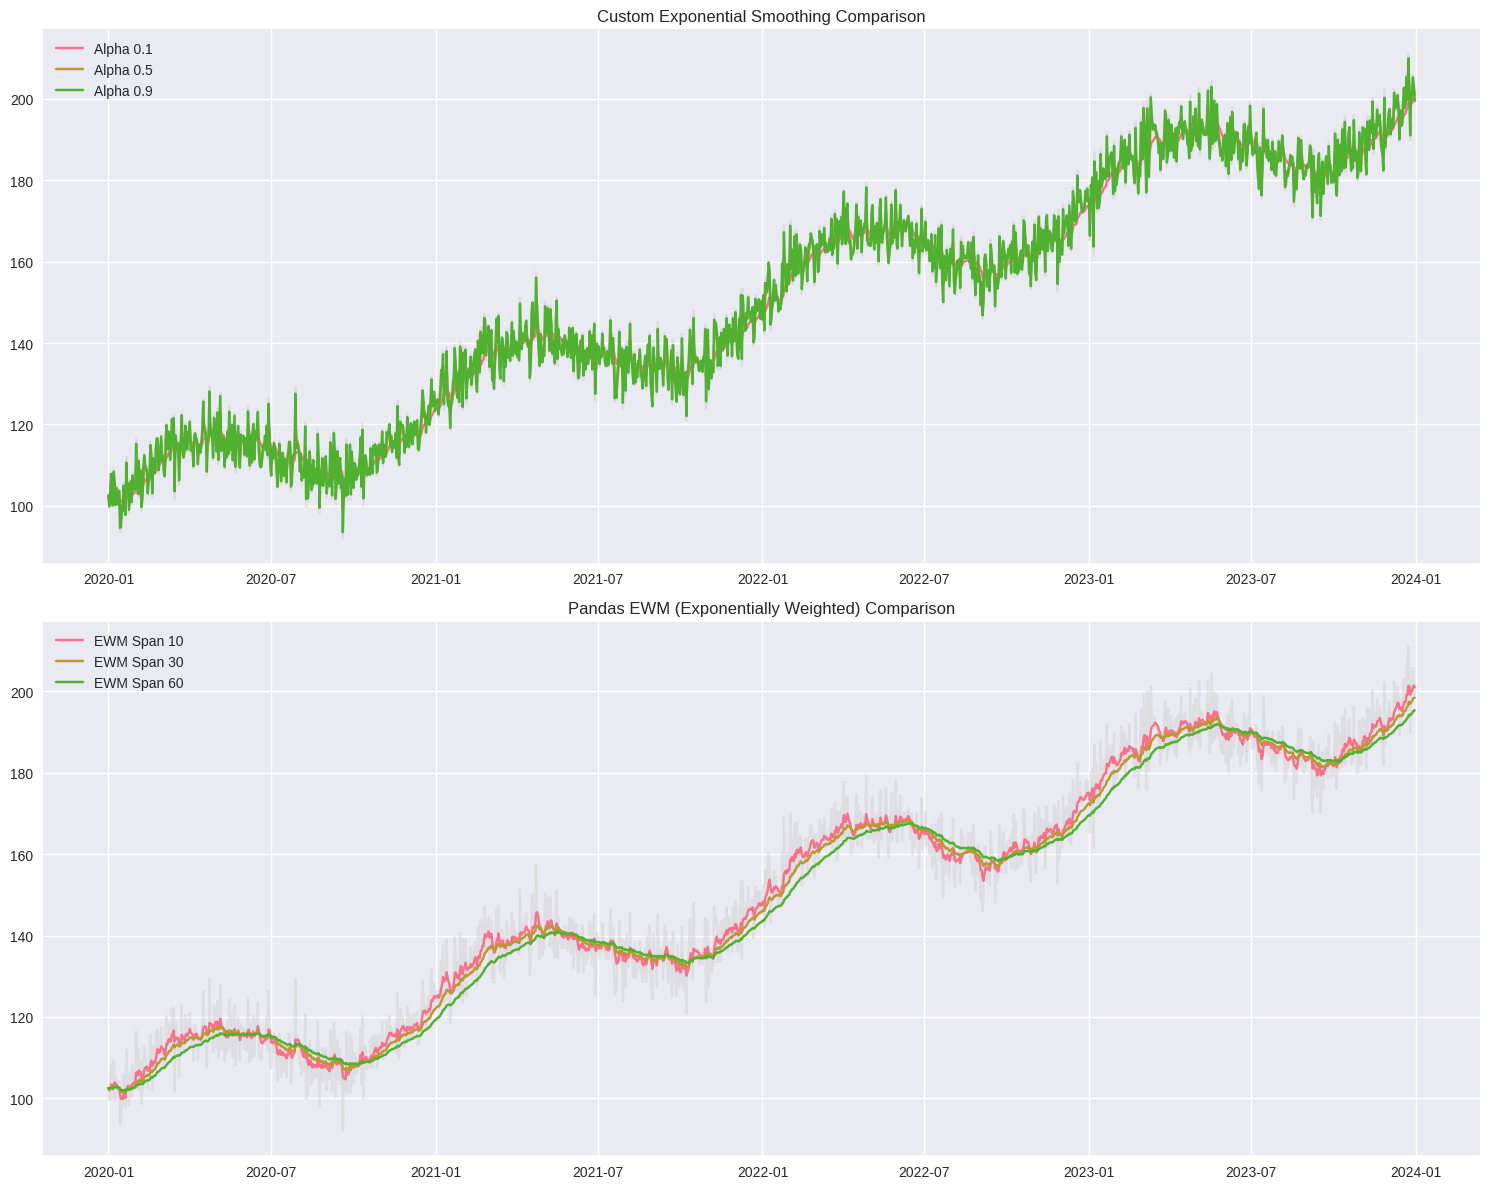

In [7]:
def exponential_smoothing(data, alpha):
    """
    Calculates Simple Exponential Smoothing.

    Parameters:
    data (pd.Series): The series to smooth
    alpha (float): Smoothing factor between 0 and 1
    """
    if not (0 < alpha <= 1):
        raise ValueError("alpha must be between 0 and 1.")

    result = np.zeros(len(data), dtype=float)
    result[0] = data.iloc[0] # Initialize first value

    for i in range(1, len(data)):
        # Formula: S_t = alpha * X_t + (1 - alpha) * S_{t-1}
        result[i] = alpha * data.iloc[i] + (1 - alpha) * result[i - 1]

    return pd.Series(result, index=data.index)

# Apply custom function
for a in [0.1, 0.3, 0.5, 0.7, 0.9]:
    df[f"EXP_{a}"] = exponential_smoothing(df["price"], a)

# Apply pandas built-in EWM (Exponentially Weighted Moving Average)
df["EWM_10"] = df["price"].ewm(span=10, adjust=False).mean()
df["EWM_30"] = df["price"].ewm(span=30, adjust=False).mean()
df["EWM_60"] = df["price"].ewm(span=60, adjust=False).mean()

# Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# Panel 1: Custom EXP
ax1.plot(df.index, df["price"], color='lightgray', alpha=0.5)
for a in [0.1, 0.5, 0.9]:
    ax1.plot(df.index, df[f"EXP_{a}"], label=f"Alpha {a}")
ax1.set_title("Custom Exponential Smoothing Comparison")
ax1.legend()

# Panel 2: Pandas EWM
ax2.plot(df.index, df["price"], color='lightgray', alpha=0.5)
for s in [10, 30, 60]:
    ax2.plot(df.index, df[f"EWM_{s}"], label=f"EWM Span {s}")
ax2.set_title("Pandas EWM (Exponentially Weighted) Comparison")
ax2.legend()

plt.tight_layout()
plt.show()

## ᐕ  Method Comparison

### ELI10
How do we know which method is "better"? We measure how much noise they removed. We calculate "Variance Reduction" — the more the variance drops, the smoother the line is.

In [8]:
def calculate_smoothness_metrics(original, smoothed):
    # Drop NaNs to align datasets
    valid_mask = smoothed.notna()
    s_clean = smoothed[valid_mask]
    o_clean = original[valid_mask]

    # Variance Reduction
    o_var = o_clean.var()
    s_var = s_clean.var()
    var_red = (o_var - s_var) / o_var

    # Deviation from a simple linear trend line
    trend_line = np.linspace(o_clean.iloc[0], o_clean.iloc[-1], len(o_clean))
    o_mad = np.mean(np.abs(o_clean - trend_line))
    s_mad = np.mean(np.abs(s_clean - trend_line))

    return {"Var Reduction": var_red, "Original Var": o_var, "Smoothed Var": s_var, "Original MAD": o_mad, "Smoothed MAD": s_mad}

comparison_list = []
methods = ["MA_7", "MA_30", "MA_90", "EXP_0.3", "EWM_30"]
for m in methods:
    metrics = calculate_smoothness_metrics(df["price"], df[m])
    metrics["Method"] = m
    comparison_list.append(metrics)

perf_df = pd.DataFrame(comparison_list).set_index("Method")
display(perf_df)

,Var Reduction,Original Var,Smoothed Var,Original MAD,Smoothed MAD
Method,,,,,
MA_7,0.025842,835.952149,814.349336,7.691726,6.976395
MA_30,0.032202,811.432840,785.303214,7.103548,6.365909
MA_90,0.057962,774.447705,729.558845,8.873808,9.401948
EXP_0.3,0.024683,842.026742,821.243141,7.007515,6.343202
EWM_30,0.034389,842.026742,813.070589,7.007515,6.095950


### 2x2 Subset Comparison (Year 2022)
We zoom into one year to see the details.

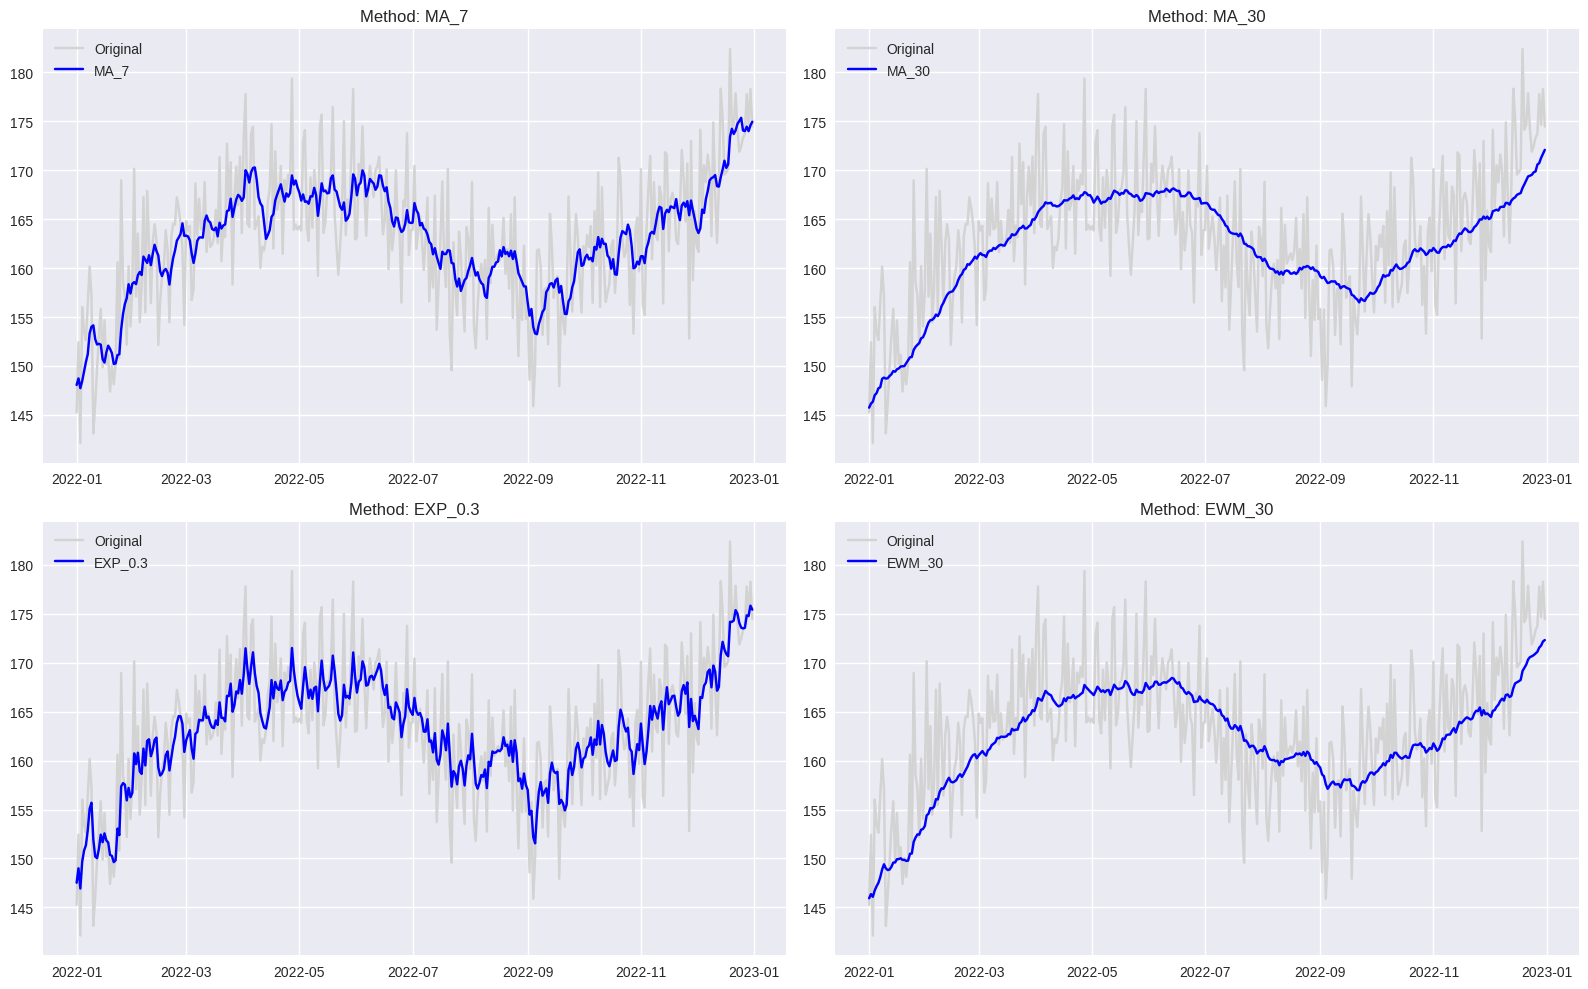

In [9]:
subset_2022 = df.loc['2022-01-01':'2022-12-31']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
plots = ["MA_7", "MA_30", "EXP_0.3", "EWM_30"]

for i, ax in enumerate(axes.flatten()):
    ax.plot(subset_2022.index, subset_2022["price"], color='lightgray', label="Original")
    ax.plot(subset_2022.index, subset_2022[plots[i]], color='blue', label=plots[i])
    ax.set_title(f"Method: {plots[i]}")
    ax.legend()
plt.tight_layout()
plt.show()

## ⏱  Lag and Responsiveness Analysis

### ELI10
When you smooth data, you get a "lag." This means the smoothed line follows the original line but with a delay. We want to know exactly how many days of delay each method has.

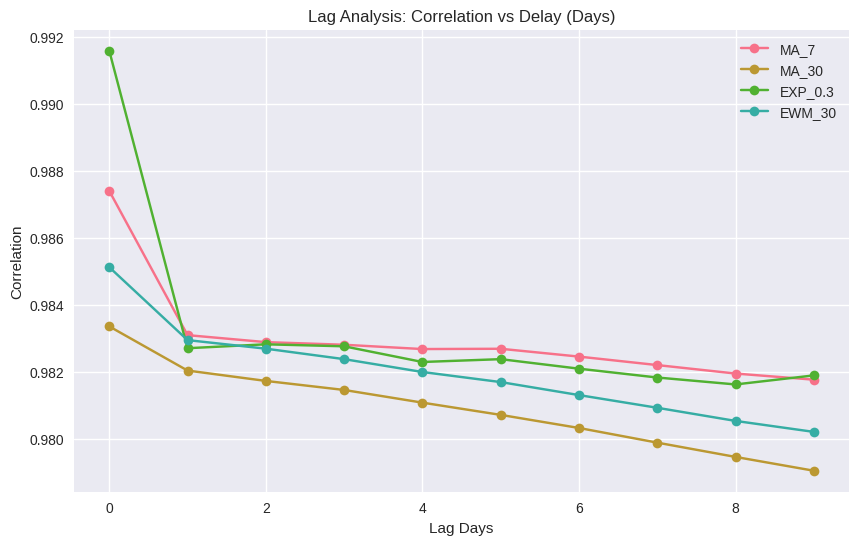

Interpretation: The peak correlation point tells us the 'lag'.
MA_30 peaks later than MA_7 because larger windows introduce more delay.


In [10]:
def calculate_lag_metrics(original, smoothed, max_lag=10):
    corrs = []
    for l in range(max_lag):
        # Correlate original with shifted smoothed version
        c = original.corr(smoothed.shift(l))
        corrs.append(c)
    return corrs

plt.figure(figsize=(10, 6))
for m in ["MA_7", "MA_30", "EXP_0.3", "EWM_30"]:
    lags = calculate_lag_metrics(df["price"], df[m])
    plt.plot(range(10), lags, label=m, marker='o')

plt.title("Lag Analysis: Correlation vs Delay (Days)")
plt.xlabel("Lag Days")
plt.ylabel("Correlation")
plt.legend()
plt.show()

print("Interpretation: The peak correlation point tells us the 'lag'.")
print("MA_30 peaks later than MA_7 because larger windows introduce more delay.")

## ᐢ  Trend Analysis Across Time Horizons

### ELI10
We look at the data through three lenses: Daily (very jumpy), Monthly (trends), and Yearly (long-term growth).

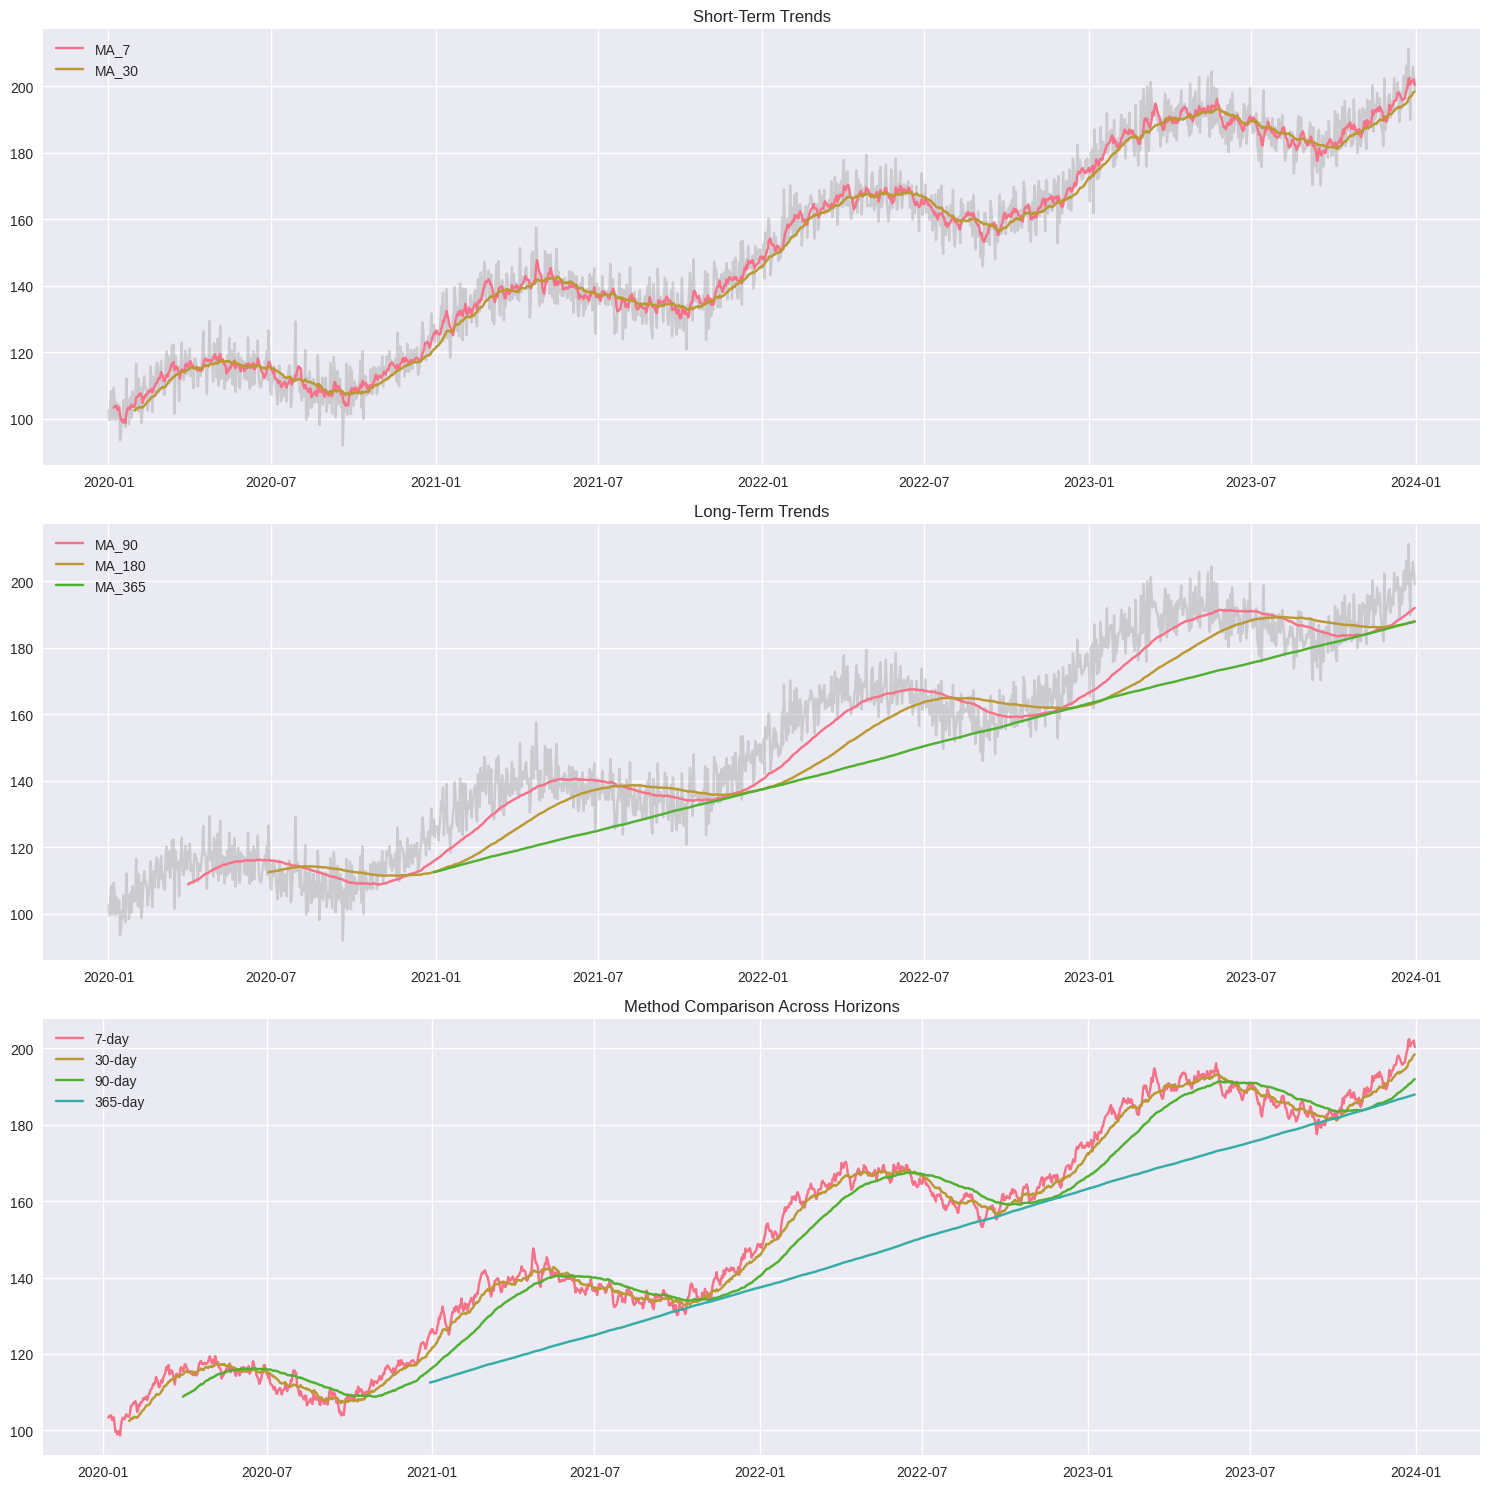

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(15, 15))

# Short Term
axes[0].plot(df.index, df["price"], alpha=0.3, color='gray')
axes[0].plot(df.index, df["MA_7"], label="MA_7")
axes[0].plot(df.index, df["MA_30"], label="MA_30")
axes[0].set_title("Short-Term Trends")
axes[0].legend()

# Long Term
axes[1].plot(df.index, df["price"], alpha=0.3, color='gray')
axes[1].plot(df.index, df["MA_90"], label="MA_90")
axes[1].plot(df.index, df["MA_180"], label="MA_180")
axes[1].plot(df.index, df["MA_365"], label="MA_365")
axes[1].set_title("Long-Term Trends")
axes[1].legend()

# Combined
axes[2].plot(df.index, df["MA_7"], label="7-day")
axes[2].plot(df.index, df["MA_30"], label="30-day")
axes[2].plot(df.index, df["MA_90"], label="90-day")
axes[2].plot(df.index, df["MA_365"], label="365-day")
axes[2].set_title("Method Comparison Across Horizons")
axes[2].legend()

plt.tight_layout()
plt.show()

## ᐢ  Trend Strength and Summary

### ELI10
Is the trend steep or flat? We use `polyfit` to find the slope (the 'tilt') of the line over time.

In [12]:
def calculate_trend_strength(data, window):
    slopes = [np.nan] * 30 # Initial padding
    for i in range(30, len(data)):
        y = data.iloc[i-30:i].values
        x = np.arange(30)
        slope, _ = np.polyfit(x, y, 1)
        slopes.append(slope)
    return pd.Series(slopes, index=data.index)

df["Trend_7"] = calculate_trend_strength(df["MA_7"], 30)
df["Trend_30"] = calculate_trend_strength(df["MA_30"], 30)
df["Trend_90"] = calculate_trend_strength(df["MA_90"], 30)

# Trend Summary Logic
def analyze_trends(df):
    long_term = df["MA_365"].dropna()
    overall_dir = "Upward" if long_term.iloc[-1] > long_term.iloc[0] else "Downward"
    mag = ((long_term.iloc[-1] - long_term.iloc[0]) / long_term.iloc[0]) * 100

    short_vol = df["MA_7"].std()
    long_vol = df["MA_365"].std()

    print(f"--- Trend Summary ---")
    print(f"Overall Trend: {overall_dir} (Magnitude: {mag:.2f}%)")
    print(f"Short-term Volatility: {short_vol:.2f}")
    print(f"Volatility Ratio: {short_vol/long_vol:.2f}")

analyze_trends(df)

--- Trend Summary ---
Overall Trend: Upward (Magnitude: 67.04%)
Short-term Volatility: 28.54
Volatility Ratio: 1.30


## ᔒ  Practical Application: Signal Generation

### ELI10
In the real world, traders use moving averages to decide when to buy.
- **Buy Signal**: When the fast line (30-day) crosses ABOVE the slow line (90-day).
- **Sell Signal**: When it crosses BELOW.

⚠️ *Disclaimer: This is for educational purposes only and not financial advice.*

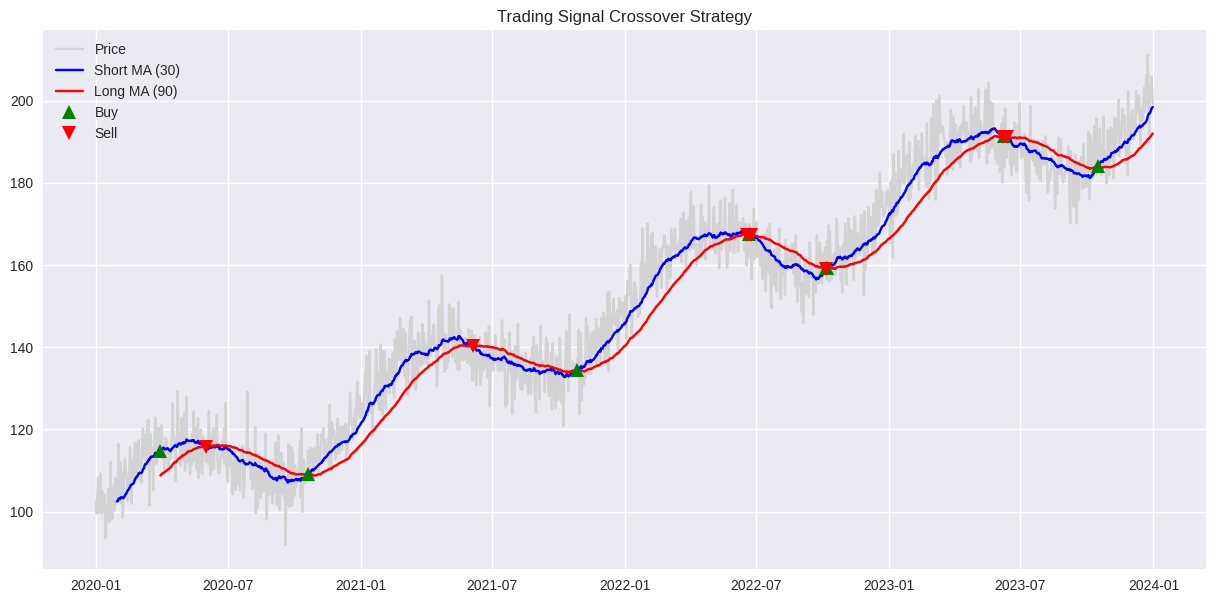

In [13]:
def generate_trading_signals(df):
    signals = pd.DataFrame(index=df.index)
    signals["price"] = df["price"]
    signals["short_ma"] = df["MA_30"]
    signals["long_ma"] = df["MA_90"]

    signals["signal"] = 0
    # Generate signals where MA_30 > MA_90
    mask = (signals["short_ma"] > signals["long_ma"]) & signals["long_ma"].notna()
    signals.loc[mask, "signal"] = 1

    # Calculate positions (1 for buy signal, -1 for sell signal)
    signals["positions"] = signals["signal"].diff()
    return signals

sig_df = generate_trading_signals(df)

plt.figure(figsize=(15, 7))
plt.plot(sig_df.index, sig_df["price"], color='lightgray', label="Price")
plt.plot(sig_df.index, sig_df["short_ma"], label="Short MA (30)", color='blue')
plt.plot(sig_df.index, sig_df["long_ma"], label="Long MA (90)", color='red')

# Plot signals
plt.plot(sig_df[sig_df["positions"] == 1].index, sig_df["short_ma"][sig_df["positions"] == 1], '^', markersize=10, color='g', label='Buy')
plt.plot(sig_df[sig_df["positions"] == -1].index, sig_df["short_ma"][sig_df["positions"] == -1], 'v', markersize=10, color='r', label='Sell')
plt.title("Trading Signal Crossover Strategy")
plt.legend()
plt.show()

## ✅  Verification
We ensure the notebook state is consistent.

In [14]:
# Verification tests
assert isinstance(df, pd.DataFrame), "df is missing"
assert 'MA_365' in df.columns, "MA_365 missing"
assert 'EXP_0.3' in df.columns, "EXP missing"
assert 'Trend_90' in df.columns, "Trend missing"
print("Notebook Verification: PASSED")

Notebook Verification: PASSED


## Ὦ0️  Troubleshooting

- **NaN Values**: Always expect `NaN` values at the start of a rolling window. Use `.dropna()` if you need a clean dataset for math.
- **Memory**: For extremely large datasets (millions of rows), many columns will slow down the notebook. Drop intermediate columns if needed.
- **Optimization**: Use pandas built-in methods (like `.rolling()` and `.ewm()`) instead of custom loops for better speed.

## Ἴ1  Conclusion
In this lab, you created a synthetic stock-price dataset and applied various smoothing techniques. You observed how Simple Moving Averages and Exponential Smoothing reduce noise but introduce lag. You also built a practical crossover signal strategy and evaluated these methods using variance reduction and MAD metrics.

### What You Learned:
- How to implement rolling statistics.
- The difference between simple and exponential weights.
- How to visualize trends across different time horizons.
- The importance of measuring lag and responsiveness.

These skills are the foundation for more advanced Time Series forecasting and Financial Data Science.